# Risultati, statistiche e performance di ItalianClassification

Per la valutazione viene usato lo stesso modello e lo stesso split di test registrato nei metadati del file `.joblib` prodotto da `scripts/training_lgbmclassifier.py`.

In questo modo la valutazione mostrata qui rimane coerente con `scripts/evaluate_model.py`: stessa soglia, stesso `test_csv`, stesso report testuale e stesse metriche finali.


In [10]:
import os
import sys

import joblib
import pandas as pd
from sklearn.inspection import permutation_importance

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.blocks.classifiers import QualityClassifier

model_path = os.path.join(project_root, "models", "lgbm_quality_model.joblib")
artifact = joblib.load(model_path)
training_metadata = artifact.get("training_metadata", {})
threshold = artifact.get("threshold") or training_metadata.get("validation_threshold") or 0.65
test_csv = training_metadata.get("test_csv") or os.path.join(project_root, "data", "splits", "doc_stats_test.csv")

if not os.path.exists(test_csv):
    raise FileNotFoundError(f"Dataset di test non trovato: {test_csv}")

print("\nCaricamento modello...")
classifier = QualityClassifier(model_path=model_path, threshold=threshold)
print("Modello caricato con successo!")
print(f"Threshold in uso: {threshold}")
print(f"Test CSV in uso: {test_csv}")
if training_metadata:
    print("Split di training trovati nel modello:")
    print(f"   Source: {training_metadata.get('source_csv')}")
    print(f"   Train:  {training_metadata.get('train_csv')}")
    print(f"   Val:    {training_metadata.get('validation_csv')}")
    print(f"   Test:   {training_metadata.get('test_csv')}")
    # print(f"   Split_metadata:  {classifier.split_metadata}")


Caricamento modello...
Modello caricato con successo!
Threshold in uso: 0.65
Test CSV in uso: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Split di training trovati nel modello:
   Source: /home/stefano/ita-llm-pipeline/output/feature/doc_stats_per_file.csv
   Train:  /home/stefano/ita-llm-pipeline/data/splits/doc_stats_train.csv
   Val:    /home/stefano/ita-llm-pipeline/data/splits/doc_stats_val.csv
   Test:   /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv


In [12]:
from src.blocks.evaluation import evaluate_model

print("\nValutazione in corso...")
result = evaluate_model(
    classifier=classifier,
    csv_path=test_csv,
    label_column="label",
    output_dir=None # oppure output_dir="evaluatione" se vuoi salvare
)
print("\nValutazione completata con successo!")

X, y, _ =classifier._load_labeled_dataset(
    csv_path=test_csv,
    feature_names=classifier.feature_names,
    label_column="label",
)
X_scaled = pd.DataFrame(
    classifier.scaler.transform(X),
    columns=classifier.feature_names,
    index=X.index,
)

model = classifier.model
feature_names = classifier.feature_names
cm = result["confusion_matrix"]
report_dict = result["classification_report"]


Valutazione in corso...

REPORT DI VALUTAZIONE DEL MODELLO
Dataset: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Modello: /home/stefano/ita-llm-pipeline/models/lgbm_quality_model.joblib
Soglia: 0.65
Timestamp: 2026-04-19 17:33:44

--------------------------------------------------------------------------------
METRICHE GLOBALI
--------------------------------------------------------------------------------
Accuracy:          0.9189 (91.89%)
Balanced Accuracy: 0.8813 (88.13%)
F1-Score:          0.8529
ROC-AUC:           0.9705

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted:Bad  Predicted:Good
Actual:Bad          2251              59
Actual:Good          208             774

--------------------------------------------------------------------------------
TOP 10 FEATURES
--------------------------------------------

## Calcolo e visualizzo la permutation importance delle feature utilizzate

In [13]:
perm = permutation_importance(
    classifier.model,
    X_scaled,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": classifier.feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(by="importance_mean", ascending=False)
    
print("\n" + "=" * 80)
print("TOP 10 FEATURES (Feature Importance)")
print("-" * 80)
for _, row in importance_df.head(10).iterrows():
    importance_pct = (row["importance_mean"] / importance_df["importance_mean"].sum()) * 100
    bar_length = int(importance_pct / 2)
    bar = "█" * bar_length
    print(f"{row['feature']:30s} {bar:40s} {importance_pct:6.2f}% "
          f"(±{row['importance_std']:.4f})")
print("\n" + "=" * 80)


TOP 10 FEATURES (Feature Importance)
--------------------------------------------------------------------------------
avg_line_length                ██████████████████                        37.84% (±0.0049)
stopword_ratio                 ████████████                              24.52% (±0.0054)
language_score                 ████                                       8.38% (±0.0038)
avg_word_length                ██                                         5.37% (±0.0013)
exclamation_ratio              ██                                         5.37% (±0.0026)
consonant_ratio                ██                                         4.25% (±0.0025)
white_space_ratio              █                                          3.85% (±0.0019)
line_count                     █                                          3.67% (±0.0023)
parenthesis_ratio              █                                          3.56% (±0.0016)
digit_ratio                    █                                       

## Confusion Matrix



Confusion matrix (tabellare):


,Predicted bad,Predicted good
Actual bad,2251,59
Actual good,208,774


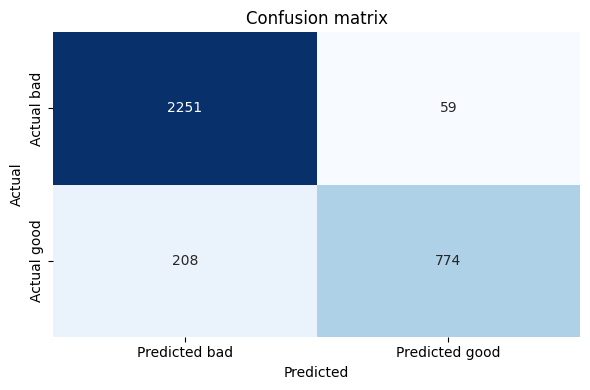

In [36]:
import seaborn as sns

cm_df = pd.DataFrame(
    cm,
    index=["Actual bad", "Actual good"],
    columns=["Predicted bad", "Predicted good"],
)
print("\nConfusion matrix (tabellare):")
display(cm_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Correlation Matrix of Features



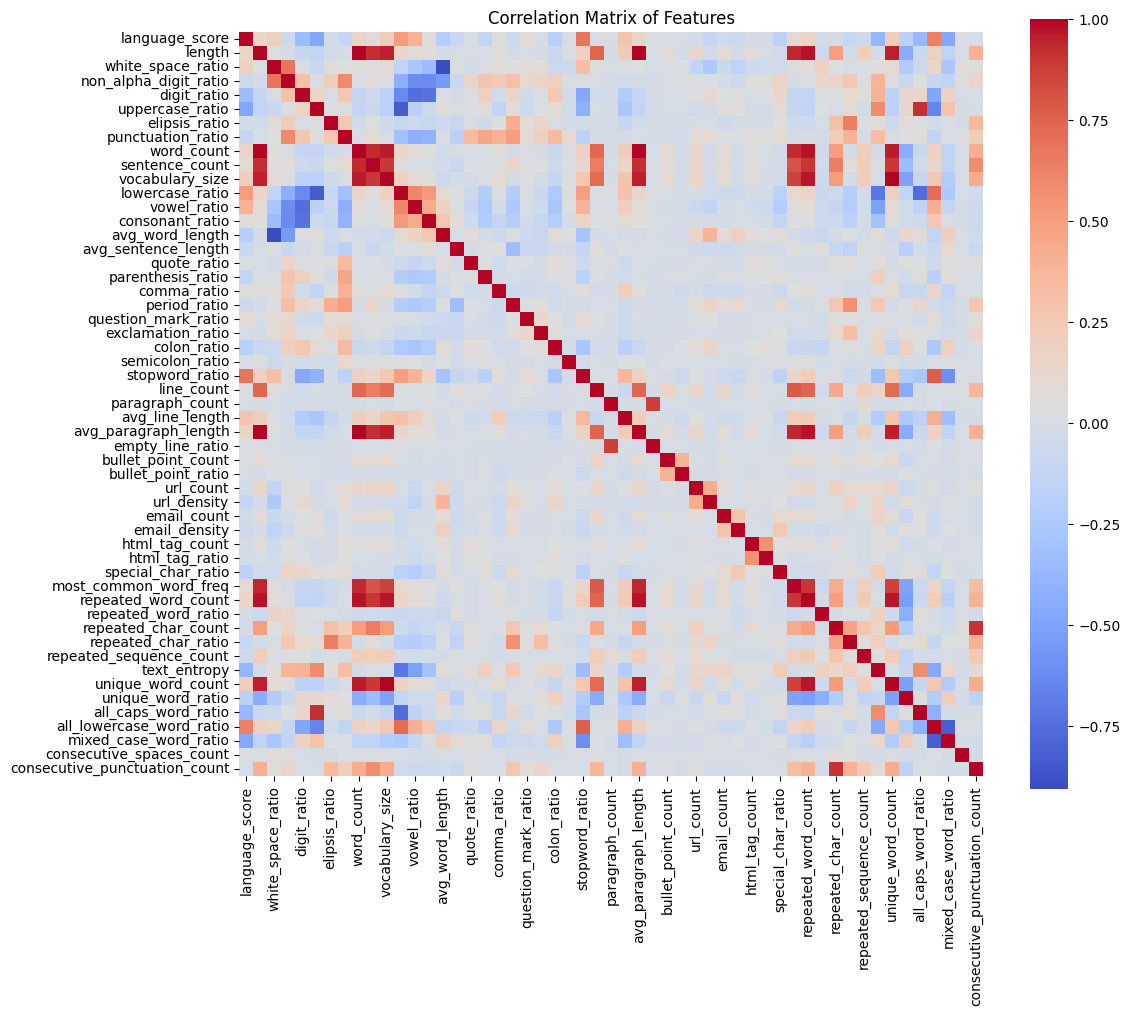

In [37]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled.corr(), annot=False, cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:
def evaluate_model(
        self,
        csv_path: str,
        label_column: str = "label",
        output_dir: Optional[str] = None,
        comparison_result: Optional[Dict[str, Any]] = None,
) -> dict:
    """
    Valuta il modello su un dataset di test contenuto in un CSV.

    Calcola tutte le metriche importanti: accuracy, precision, recall, F1,
    ROC-AUC, confusion matrix, e feature importance.

    Parametri
    ---------
    csv_path : str
        Percorso al file CSV con le feature e la label.
        Il CSV deve contenere colonne per tutte le feature (come in DEFAULT_FEATURE_NAMES)
        e una colonna per la label con valori "good" / "bad".
    label_column : str
        Nome della colonna contenente le label (default "label").
    output_dir : str | None
        Directory dove salvare il report in formato JSON e HTML.
        Se None, il report viene solo stampato a schermo.
    comparison_result : dict | None
        Risultato opzionale del benchmark multi-modello da includere nel report.

    -------
    Ritorna un dizionario contenente:
        - "accuracy": Accuratezza complessiva
        - "balanced_accuracy": Accuratezza bilanciata
        - "roc_auc": Punteggio ROC-AUC
        - "classification_report": Report dettagliato (dict)
        - "confusion_matrix": Matrice di confusione
        - "threshold": Soglia usata
        - "feature_names": Nomi delle feature impiegate
        - "timestamp": Data/ora della valutazione
    """
    X, y, _ = self._load_labeled_dataset(
        csv_path=csv_path,
        feature_names=self.feature_names,
        label_column=label_column,
    )

    expected_test_csv = self.training_metadata.get("test_csv")
    if expected_test_csv and os.path.abspath(csv_path) != expected_test_csv:
        logger.warning(
            "Il modello e stato addestrato con test set %s, ma la valutazione usa %s",
            expected_test_csv,
            os.path.abspath(csv_path),
        )

    # Scalo le feature usando lo scaler del modello
    X_scaled = self.scaler.transform(X)
    X_scaled = pd.DataFrame(
        X_scaled,
        columns=self.feature_names,
        index=X.index,
    )

    # Predizioni
    y_pred_proba = self.model.predict_proba(X_scaled)[:, 1]  # Probabilità della classe "good"
    y_pred = (y_pred_proba >= self.threshold).astype(int)

    # Calcolo metriche
    metrics = self._compute_binary_metrics(
        y_true=y,
        y_pred=y_pred,
        y_pred_proba=y_pred_proba,
    )
    accuracy = metrics["accuracy"]
    balanced_acc = metrics["balanced_accuracy"]
    roc_auc = metrics["roc_auc"]
    f1 = metrics["f1_score"]
    cm = confusion_matrix(y, y_pred)
    report_dict = classification_report(
        y, y_pred, target_names=["bad", "good"], output_dict=True, zero_division=0
    )
    report_str = classification_report(
        y, y_pred, target_names=["bad", "good"], zero_division=0
    )

    # Feature importance (permutation)
    logger.info("Calcolo permutation feature importance...")
    perm = permutation_importance(
        self.model,
        X_scaled,
        y,
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame(
        {
            "feature": self.feature_names,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    ).sort_values(by="importance_mean", ascending=False)

    # Calcolo curve ROC e Precision-Recall
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    precision_vals, recall_vals, _ = precision_recall_curve(y, y_pred_proba)

    # Stampo report formattato
    self._print_evaluation_report(
        accuracy=accuracy,
        balanced_acc=balanced_acc,
        roc_auc=roc_auc,
        f1=f1,
        report_str=report_str,
        cm=cm,
        importance_df=importance_df,
        csv_path=csv_path,
    )

    # Preparo il risultato
    result = {
        "accuracy": round(accuracy, 4),
        "balanced_accuracy": round(balanced_acc, 4),
        "roc_auc": round(roc_auc, 4),
        "f1_score": round(f1, 4),
        "classification_report": report_dict,
        "confusion_matrix": cm.tolist(),
        "threshold": self.threshold,
        "feature_names": self.feature_names,
        "top_features": importance_df.head(10).to_dict(orient="records"),
        "csv_path": csv_path,
        "timestamp": datetime.now().isoformat(),
        "model_name": self.model_name,
        "training_metadata": self.training_metadata,
    }
    if comparison_result is not None:
        result["model_comparison"] = comparison_result

    # Salvo i report se specificato output_dir
    if output_dir:
        self.save_evaluation_report(result, output_dir, importance_df, fpr, tpr, precision_vals, recall_vals)

    return result

## Summary Plot of the features

/home/stefano/ita-llm-pipeline/datatrove_venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


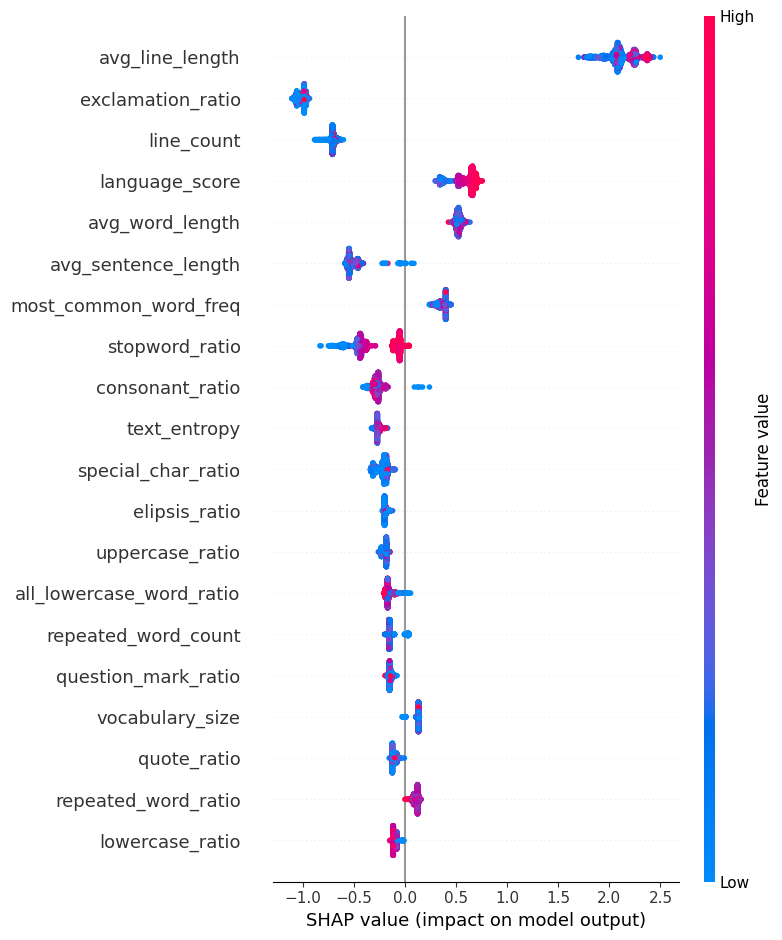

In [38]:
import shap

# model = tuo modello LGBM già addestrato
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)
shap_values_good = shap_values[1]
shap_values_bad = shap_values[0]

shap.summary_plot(shap_values, X)


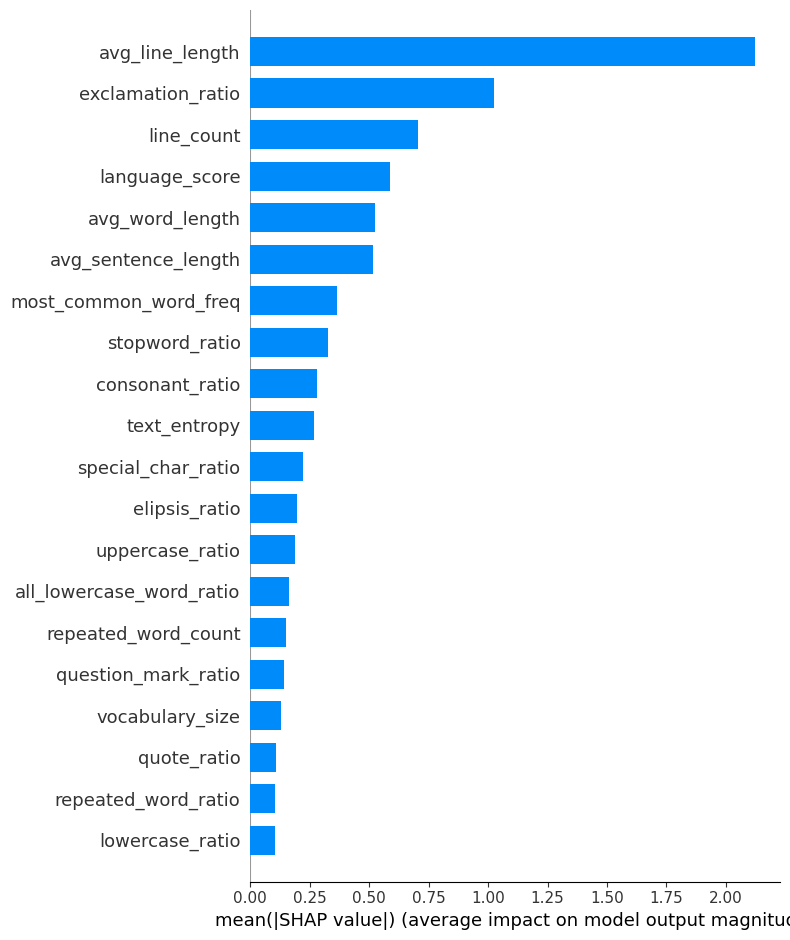

In [35]:
shap.summary_plot(shap_values, X, plot_type="bar")